# Microscope Model: Gaussian Beam Propagation

Load the microscope from TOML, build components for a chosen mode,
propagate Gaussian beams through the column, and visualise both the
ray trajectories and the detector-plane intensity.

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_MEM_FRACTION"] = "0.1"

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from temgym_core.microscope_model import MicroscopeModel
from temgym_core.source import point_source_wave
from temgym_core.components import SigmoidAperture, Detector, Plane
from temgym_core.run import run_iter_vmapped
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
import jax 

%matplotlib widget
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")

if jax.default_backend() != "gpu":
    raise RuntimeError(f"GPU backend not available. Current backend: {jax.default_backend()}")

print("JAX backend:", jax.default_backend())
print("Devices:", jax.devices())



JAX backend: gpu
Devices: [CudaDevice(id=0)]


## 1. Load the model and choose an operating point

In [2]:
model = MicroscopeModel.from_toml(
    "microscope.toml",
    mode_names={
        "illumination.parallel": "spot",
        "imaging.magnification": "mag",
        "imaging.diffraction": "diff",
    },
    mode_defaults={"spot": {"Obj_prefield": 1.0}},
)

# The microscope always runs in a condenser mode + an imaging mode simultaneously.
operating_modes = {"spot": 3.0, "mag": 100_000.0}

print(f"Voltage   : {model.voltage/1e3:.0f} kV")
print(f"Lenses    : {[l.name for l in model.lenses]}")
print(f"Deflectors: {[d.name for d in model.deflectors]}")
print(f"Modes     : {list(model.modes.keys())}")
print(f"Active    : {operating_modes}")

Voltage   : 200 kV
Lenses    : ['CL1', 'CL3', 'C_mini', 'Obj_prefield', 'Obj_post', 'IL1', 'IL2', 'IL3', 'PL1']
Deflectors: ['CL12_deflector']
Modes     : ['spot', 'mag', 'diff']
Active    : {'spot': 3.0, 'mag': 100000.0}


## 2. Build the optical column

In [3]:
# Optical components from combined condenser + imaging modes
optics = list(model.build_components(operating_modes))

# Aperture from the TOML auxiliary data
ap_info = model.auxiliary["apertures"]["C_aperture"]
aperture = SigmoidAperture(
    radius=ap_info["radii"][2],  # 30 um aperture
    edge_width=ap_info["radii"][2] * 0.05,
    sharpness=10.0,
    z=ap_info["z"],
)

# Detector from the TOML auxiliary data
det_info = model.auxiliary["detector"]
detector = Detector(
    z=det_info["z"],
    pixel_size=(det_info["pixel_size"], det_info["pixel_size"]),
    shape=(det_info["shape"][0], det_info["shape"][1]),
)

# Sample from the TOML auxiliary data
samp_info = model.auxiliary["sample"]
sample = Plane(z=samp_info["z"])

# Full column: optics + aperture + sample + detector, sorted by z
all_components = optics + [aperture, sample, detector]
# Build a z -> name lookup from the model config
z_to_name = {float(l.z_position): l.name for l in model.lenses}
z_to_name[float(aperture.z)] = ap_info.get("name", "C aperture")
z_to_name[float(sample.z)] = samp_info.get("name", "Sample")
z_to_name[float(detector.z)] = det_info.get("name", "Detector")
for d in model.deflectors:
    z_to_name[float(d.z_position)] = d.name

# Sort and build parallel names list
column = sorted(all_components, key=lambda c: float(c.z))
column_names = [z_to_name.get(float(c.z), type(c).__name__) for c in column]

for c, cname in zip(column, column_names):
    current = f"I={float(c.current):.4f} A" if hasattr(c, 'current') else ""
    print(f"  z = {float(c.z):.4f} m  {cname:25s} {current}")

  z = 0.2000 m  CL1                       I=0.7264 A
  z = 0.2400 m  CL3                       I=0.7917 A
  z = 0.2500 m  C aperture                
  z = 0.2900 m  CL12_deflector            
  z = 0.3000 m  C_mini                    I=1.0000 A
  z = 0.3200 m  Obj_prefield              I=1.0000 A
  z = 0.3250 m  Sample                    
  z = 0.3273 m  Obj_post                  I=-2.4725 A
  z = 0.5297 m  IL1                       I=2.6137 A
  z = 0.6068 m  IL2                       I=1.9160 A
  z = 0.6693 m  IL3                       I=1.7816 A
  z = 0.7243 m  PL1                       I=-3.1163 A
  z = 1.0437 m  Detector                  


## 3. Create the input Gaussian beam

In [4]:
z_source = model.auxiliary.get("z_source", 0.0)
voltage = model.voltage

beam_in = point_source_wave(
    n=10000,                  # 10000 Gaussian sub-beams
    half_angle=0.5e-3,      # 0.5 mrad semi-convergence
    waist=100e-9,            # 100 nm initial waist
    voltage=voltage,
    z0=z_source,
)

n_rays = beam_in.x.shape[0]
print(f"Input beam: {n_rays} Gaussian sub-beams at z = {z_source} m")

Input beam: 10000 Gaussian sub-beams at z = 0.0 m


## 4. Propagate and collect ray trajectories

In [5]:
def trace_column(beam, components):
    """Propagate beam through components, recording (z, x) at each step.

    Uses jax.vmap internally so each component sees a single ray.
    Returns zs, xs arrays for plotting, plus a dict mapping each component
    to its (before, after) beam states for evaluation at any plane.
    """
    zs = [float(beam.z[0])]
    xs = [np.array(beam.x)]

    # run_iter_vmapped returns 2 rays per component: drift-to, then interact
    step_rays = run_iter_vmapped(beam, components)
    beams = {}
    for i, ray in enumerate(step_rays):
        zs.append(float(ray.z[0]))
        xs.append(np.array(ray.x))
        # Even indices = arrived at component (before), odd = after interaction
        comp_idx = i // 2
        if i % 2 == 0:
            beams[comp_idx] = {"before": ray}
        else:
            beams[comp_idx]["after"] = ray

    beam_out = step_rays[-1]
    return np.array(zs), np.stack(xs, axis=0), beam_out, beams


zs, xs, beam_out, beams = trace_column(beam_in, column)
print(f"Traced {len(zs)} steps, final z = {zs[-1]:.4f} m")

# Map component labels to their index in the column for easy lookup
comp_index = {name: i for i, name in enumerate(column_names)}
print("Component index:", comp_index)

Traced 27 steps, final z = 1.0437 m
Component index: {'CL1': 0, 'CL3': 1, 'C aperture': 2, 'CL12_deflector': 3, 'C_mini': 4, 'Obj_prefield': 5, 'Sample': 6, 'Obj_post': 7, 'IL1': 8, 'IL2': 9, 'IL3': 10, 'PL1': 11, 'Detector': 12}


## 5. Ray trajectory plot

In [6]:
def visualise_beam(beam, pixel_size=1e-6, shape=(512, 512), *,
                   aperture_radius=None, title="", ax=None, scale="um"):
    """Evaluate Gaussian beam intensity on a grid and display it.

    Parameters
    ----------
    beam : GaussianBeam
        Beam state at the plane to visualise.
    pixel_size : float
        Grid pixel size in metres.
    shape : tuple
        Grid shape (ny, nx).
    aperture_radius : float or None
        If given, draw a circle at this radius (metres).
    title : str
        Plot title.
    ax : matplotlib Axes or None
        Axes to draw on; creates a new figure if None.
    scale : str
        "um" for microns, "mm" for millimetres in axis labels.
    """
    grid = Detector(
        z=float(beam.z[0]),
        pixel_size=(pixel_size, pixel_size),
        shape=shape,
    )
    field = evaluate_gaussians_gpu_kernel_wrapper(beam, grid)
    intensity = np.array(jnp.abs(field) ** 2)

    s = {"um": 1e6, "mm": 1e3}[scale]
    half_y = shape[0] / 2 * pixel_size * s
    half_x = shape[1] / 2 * pixel_size * s
    extent = [-half_x, half_x, -half_y, half_y]

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    im = ax.imshow(intensity, extent=extent, origin="lower", cmap="inferno")
    ax.set_xlabel(f"x [{scale}]")
    ax.set_ylabel(f"y [{scale}]")
    ax.set_title(title or f"z = {float(beam.z[0]):.4f} m")
    ax.figure.colorbar(im, ax=ax, label="Intensity [a.u.]", shrink=0.8)

    if aperture_radius is not None:
        circle = plt.Circle((0, 0), aperture_radius * s,
                            fill=False, edgecolor="cyan", linewidth=1.5, linestyle="--")
        ax.add_patch(circle)

    return ax

## 5b. Beam at the aperture plane (before & after)

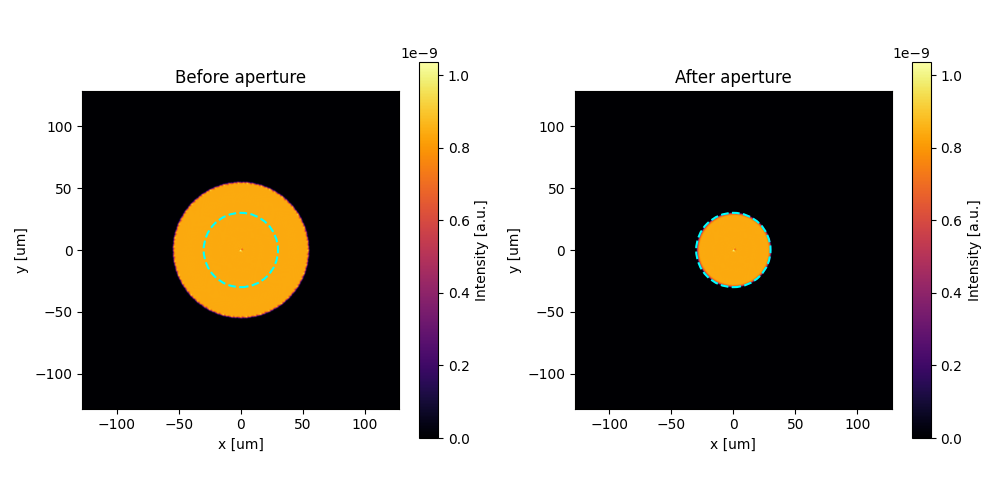

In [7]:
ap_idx = comp_index[ap_info["name"]]
beam_before_ap = beams[ap_idx]["before"]
beam_after_ap  = beams[ap_idx]["after"]
ap_radius = float(aperture.radius)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

visualise_beam(
    beam_before_ap,
    pixel_size=0.5e-6,
    shape=(512, 512),
    aperture_radius=ap_radius,
    title="Before aperture",
    ax=ax1,
)
visualise_beam(
    beam_after_ap,
    pixel_size=0.5e-6,
    shape=(512, 512),
    aperture_radius=ap_radius,
    title="After aperture",
    ax=ax2,
)

plt.tight_layout()

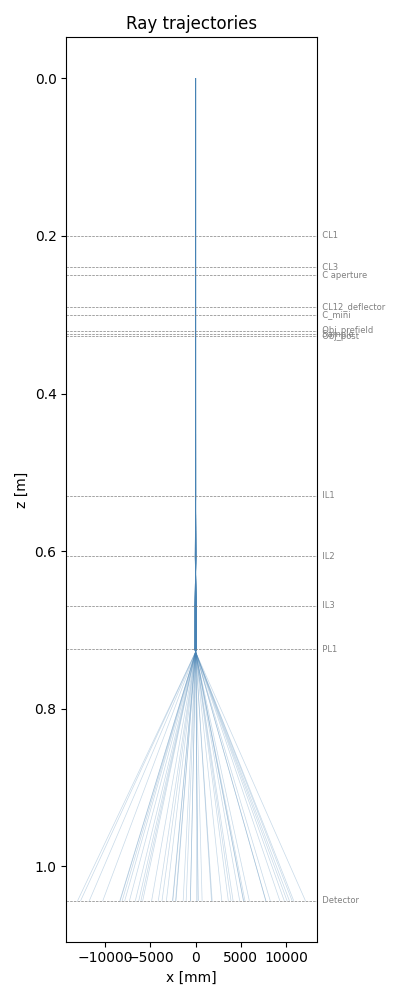

In [8]:
def plot_column(zs, xs, components, names=None, max_rays=50, ax=None):
    """Minimal ray trajectory visualisation along the column."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 10))

    # Plot ray lines (subsample if many)
    n_rays = xs.shape[1]
    stride = max(1, n_rays // max_rays)
    for j in range(0, n_rays, stride):
        ax.plot(xs[:, j] * 1e3, zs, color="steelblue", alpha=0.3, lw=0.5)

    # Mark components
    for i, c in enumerate(components):
        z_c = float(c.z)
        label = names[i] if names else type(c).__name__
        ax.axhline(z_c, color="gray", ls="--", lw=0.5)
        ax.text(
            ax.get_xlim()[1], z_c, f"  {label}",
            va="center", fontsize=6, color="gray",
        )

    ax.set_xlabel("x [mm]")
    ax.set_ylabel("z [m]")
    ax.invert_yaxis()
    ax.set_title("Ray trajectories")
    plt.tight_layout()
    return ax


plot_column(zs, xs, column, names=column_names);

## 6. Evaluate Gaussian intensity at the detector

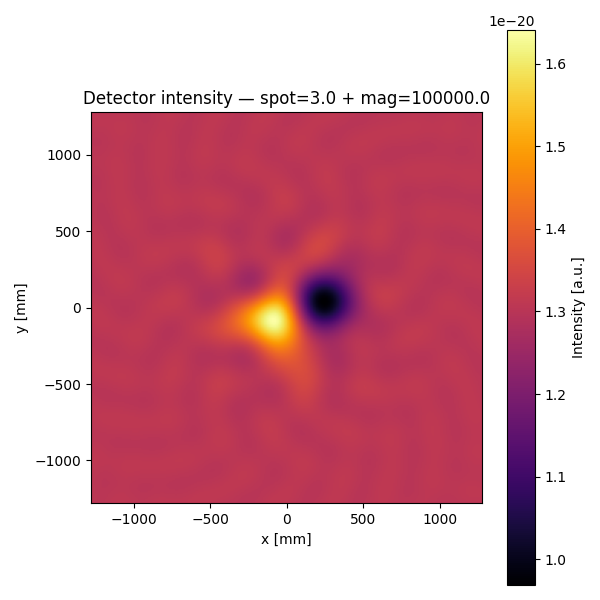

In [9]:
field = evaluate_gaussians_gpu_kernel_wrapper(beam_out, detector)
intensity = jnp.abs(field) ** 2

extent_mm = (
    np.array([
        -det_info["shape"][1] / 2,
         det_info["shape"][1] / 2,
        -det_info["shape"][0] / 2,
         det_info["shape"][0] / 2,
    ])
    * det_info["pixel_size"]
    * 1e3  # to mm
)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(
    np.array(intensity),
    extent=extent_mm,
    origin="lower",
    cmap="inferno",
)
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
mode_str = " + ".join(f"{k}={v}" for k, v in operating_modes.items())
ax.set_title(f"Detector intensity — {mode_str}")
fig.colorbar(im, ax=ax, label="Intensity [a.u.]")
plt.tight_layout();

## 7. ABCD transfer-matrix profile

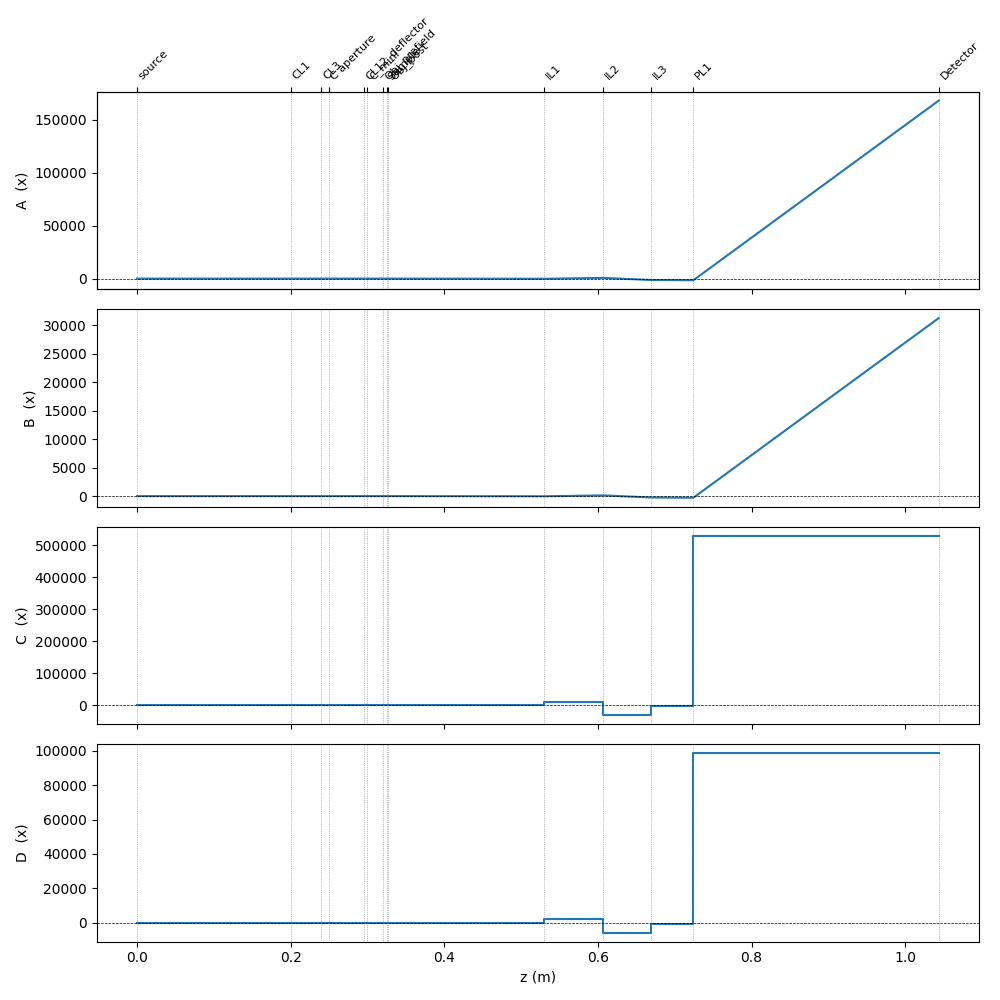

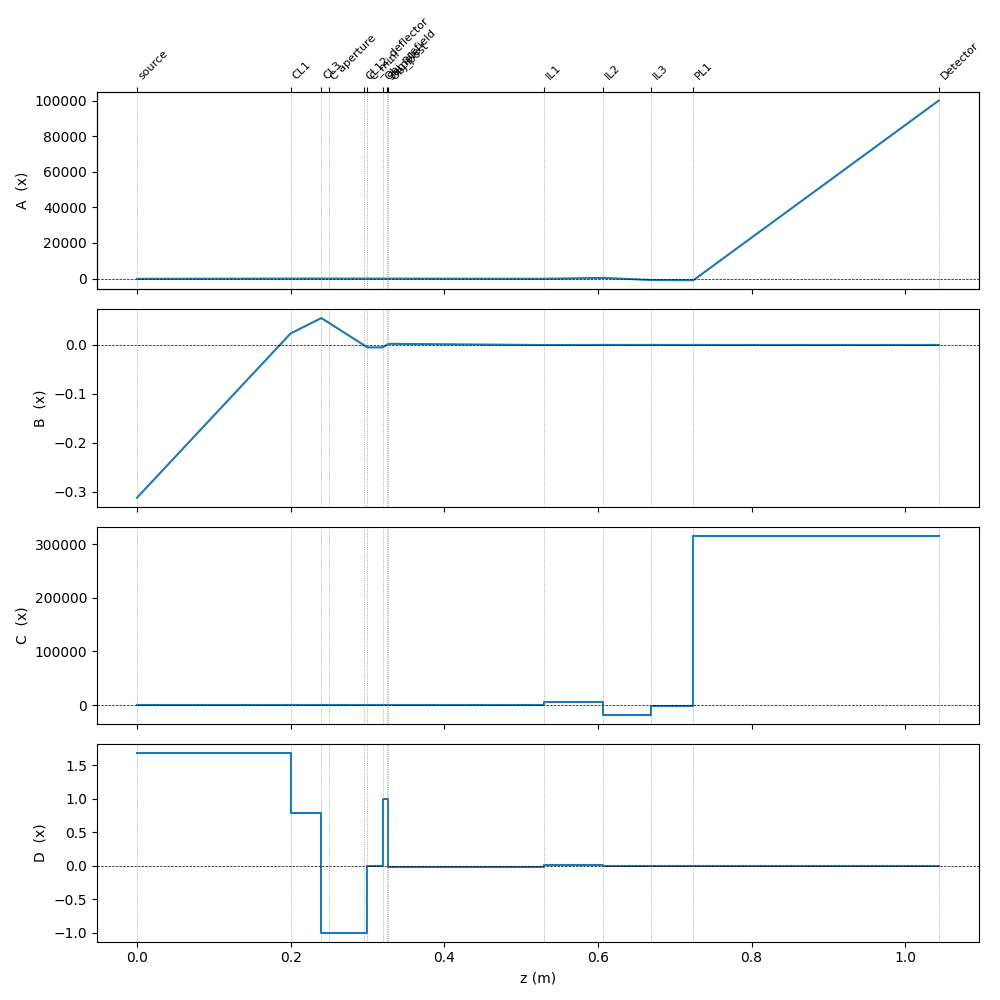

In [6]:
from temgym_core.run import solve_model_with_z
from temgym_core.plotting import plot_abcd_profile
from temgym_core.ray import Ray
# Single on-axis ray at the source for the Jacobian computation
ray0 = Ray(x=0.0, y=0.0, dx=0.0, dy=0.0, z=z_source, pathlength=0.0, voltage=voltage)

z_prof, M_cum, step_labels, rot = solve_model_with_z(ray0, column, names=column_names)

# --- Cumulative from source (default) ---
fig, axes = plot_abcd_profile(z_prof, M_cum, labels=step_labels, rotation=rot)
fig.suptitle("Cumulative ABCD from source (co-rotating frame)", y=1.02)
plt.show()

# --- Relative to the sample plane (imaging condition: B should → 0 at detector) ---
sample_name = samp_info.get("name", "Sample")
fig2, axes2 = plot_abcd_profile(
    z_prof, M_cum, labels=step_labels, rotation=rot,
    reference=sample_name,
)
fig2.suptitle(f"ABCD relative to {sample_name} (co-rotating frame)", y=1.02);

In [7]:
# Check sample→detector imaging condition numerically
from temgym_core.plotting import _rotation_matrix_5x5

M_rot = np.array([
    _rotation_matrix_5x5(-float(th)) @ np.array(M)
    for th, M in zip(rot, M_cum)
])

sample_idx = next(i for i, lbl in enumerate(step_labels) if lbl == sample_name)
det_idx = next(i for i, lbl in enumerate(step_labels) if lbl == det_info.get("name", "Detector"))

M_sample_to_det = M_rot[det_idx] @ np.linalg.inv(M_rot[sample_idx])
A_sd = M_sample_to_det[0, 0]
B_sd = M_sample_to_det[0, 2]

print(f"Sample → Detector:  A = {A_sd:.2f} (magnification),  B = {B_sd:.4e} (imaging condition)")

Sample → Detector:  A = 100000.00 (magnification),  B = 1.0982e-11 (imaging condition)


In [8]:
# ── Diagnostic: trace the 2x2 ABCD step-by-step (sample -> detector) ──
from temgym_core.components import ElectromagneticLens
from temgym_core.constants import effective_accelerating_potential

chain = [(float(c.z), c, nm) for c, nm in zip(column, column_names)]
chain.sort(key=lambda x: x[0])
sample_z, det_z = float(sample.z), float(detector.z)

M_2x2 = np.eye(2)
z_now = sample_z
rows = []

for z_c, comp, name in chain:
    z_c = float(z_c)
    if z_c <= sample_z:
        continue
    if z_c > det_z + 1e-9:
        break
    drift = z_c - z_now
    if drift > 1e-12:
        M_2x2 = np.array([[1.0, drift], [0.0, 1.0]]) @ M_2x2
    if isinstance(comp, ElectromagneticLens):
        NI = float(comp.turns) * float(comp.current)
        V_star = float(effective_accelerating_potential(voltage))
        f = V_star / (float(comp.Gc) * NI**2) if abs(NI) > 1e-30 else float('inf')
        M_2x2 = np.array([[1.0, 0.0], [-1.0/f, 1.0]]) @ M_2x2
        rows.append(f"  {name:15s} z={z_c:.6f}  f={f*1e3:10.3f}mm  NI={NI:10.2f}AT  A={M_2x2[0,0]:12.4f}  B={M_2x2[0,1]:.4e}")
    else:
        rows.append(f"  {name:15s} z={z_c:.6f}  (non-lens)  A={M_2x2[0,0]:12.4f}  B={M_2x2[0,1]:.4e}")
    z_now = z_c

for r in rows:
    print(r)

print(f"\n2x2 Manual:      A = {M_2x2[0,0]:.4f},  B = {M_2x2[0,1]:.4e}")
print(f"5x5 Co-rotating: A = {A_sd:.4f},  B = {B_sd:.4e}")
print(f"Ratio A_manual/A_5x5 = {M_2x2[0,0]/A_sd:.6f}")
print(f"\n5x5 M_sample_to_det (co-rotating):")
for i in range(5):
    print("  " + "  ".join(f"{M_sample_to_det[i,j]:12.4f}" for j in range(5)))

  Obj_post        z=0.327300  f=     2.272mm  NI=  -7417.56AT  A=      1.0000  B=2.3000e-03
  IL1             z=0.529742  f=    13.052mm  NI=   7840.96AT  A=    -88.1072  B=-2.0474e-04
  IL2             z=0.606847  f=    15.862mm  NI=   3831.91AT  A=    398.4559  B=5.0799e-05
  IL3             z=0.669347  f=    47.320mm  NI=   3563.15AT  A=   -777.1551  B=5.7776e-05
  PL1             z=0.724310  f=     2.854mm  NI=  -6232.67AT  A=   -908.3250  B=-3.1944e-06
  Detector        z=1.043750  (non-lens)  A= 100000.0000  B=-3.1234e-12

2x2 Manual:      A = 100000.0000,  B = -3.1234e-12
5x5 Co-rotating: A = 100000.0000,  B = 1.0982e-11
Ratio A_manual/A_5x5 = 1.000000

5x5 M_sample_to_det (co-rotating):
   100000.0000       -0.0000        0.0000       -0.0000        0.0000
       -0.0000   100000.0000       -0.0000        0.0000        0.0000
   315890.8774       -0.0000        0.0000       -0.0000        0.0000
       -0.0000   315890.8774       -0.0000        0.0000        0.0000
        0.00

In [13]:
# ── Diagnostic: check the z_pl1 export vs PL1 reimaging requirement ──
from pathlib import Path

# Load the fit data exported by imaging_system_design
npz_path = Path("data/il_constraint_study.npz")
if npz_path.exists():
    fit = np.load(npz_path)
    D3_MM = float(fit['D3_MM'])
    d4_f  = float(fit['d4_f'])
    d1i_f = float(fit['d1i_f'])
    d1c_f = float(fit['d1c_f'])
    d2_f  = float(fit['d2_f'])
    s_img_f = float(fit['s_img_f'])
    si_best = int(fit['si_best'])
    alpha_f = fit['alpha_f']
    print(f"Fit data loaded: D3 = {D3_MM:.2f} mm")
    print(f"  d4_f = {d4_f:.6f} (normalised to d3)")
    print(f"  d4_f * D3 = {d4_f * D3_MM:.3f} mm")
else:
    print("NPZ file not found, estimating from TOML z-positions...")
    D3_MM = (0.6693 - 0.6068) * 1e3  # IL2-IL3 gap in mm
    d4_f = None

# Physical geometry from the TOML
z_il3_m = 0.669347184546638
z_pl1_m = 0.721429942486652
z_det_m = 1.04375
z_sample_m = 0.325
z_obj_post = 0.3273
d3_m = D3_MM * 1e-3

il3_to_pl1_mm = (z_pl1_m - z_il3_m) * 1e3
pl1_to_det_mm = (z_det_m - z_pl1_m) * 1e3

# PL1 parameters from TOML
PL1_TURNS = 2000
PL1_I = -3.116334138300715
PL1_GC = 8.0e-6
NI_PL1 = PL1_TURNS * abs(PL1_I)
phi_pl1_phys = PL1_GC * NI_PL1**2  # 1/f in m^-1
f_pl1_mm = 1.0 / phi_pl1_phys * 1e3

# Required PL1 object distance for imaging to detector
u_pl1_mm = f_pl1_mm * pl1_to_det_mm / (pl1_to_det_mm - f_pl1_mm)
u_pl1_m = u_pl1_mm * 1e-3

print(f"\nPL1 optics:")
print(f"  f_PL1 = {f_pl1_mm:.4f} mm")
print(f"  PL1->Det = {pl1_to_det_mm:.3f} mm")
print(f"  Required u_PL1 (object distance) = {u_pl1_mm:.4f} mm")

print(f"\nGeometry comparison:")
print(f"  IL3->PL1 (TOML) = {il3_to_pl1_mm:.3f} mm")
if d4_f is not None:
    d4_mm = d4_f * D3_MM
    print(f"  d4 from fit      = {d4_mm:.3f} mm (this is what z_pl1 = z_il3 + d4_m uses)")
    print(f"  d4 + u_pl1       = {d4_mm + u_pl1_mm:.3f} mm (this is where PL1 should be)")
    print(f"  Difference       = {u_pl1_mm:.3f} mm  <-- MISSING u_PL1 gap!")

# Where does B actually cross zero in the IL3->PL1 drift?
# From the diagnostic: B_IL3 = 5.78e-5, and B goes to 0 at PL1 output
# B(z) = B_IL3 + z * D_IL3, zero at z = -B_IL3/D_IL3
# Since B_at_PL1_input ≈ B_at_PL1_output ≈ 0 (thin lens doesn't change B)
# → IL image is at PL1 position (52.1 mm from IL3)
print(f"\nDiagnosis: the IL image falls AT PL1 ({il3_to_pl1_mm:.1f} mm from IL3)")
print(f"  For PL1 to reimage to detector, IL image should be {u_pl1_mm:.2f} mm BEFORE PL1")
print(f"  i.e., at {il3_to_pl1_mm - u_pl1_mm:.1f} mm from IL3")
print(f"\n  ==> The TOML has z_PL1 = z_IL3 + d4, but should be z_IL3 + d4 + u_PL1")
print(f"      Missing gap: {u_pl1_mm:.3f} mm = {u_pl1_mm/D3_MM:.4f} d3 units")

Fit data loaded: D3 = 62.50 mm
  d4_f = 0.833324 (normalised to d3)
  d4_f * D3 = 52.083 mm

PL1 optics:
  f_PL1 = 3.2178 mm
  PL1->Det = 322.320 mm
  Required u_PL1 (object distance) = 3.2503 mm

Geometry comparison:
  IL3->PL1 (TOML) = 52.083 mm
  d4 from fit      = 52.083 mm (this is what z_pl1 = z_il3 + d4_m uses)
  d4 + u_pl1       = 55.333 mm (this is where PL1 should be)
  Difference       = 3.250 mm  <-- MISSING u_PL1 gap!

Diagnosis: the IL image falls AT PL1 (52.1 mm from IL3)
  For PL1 to reimage to detector, IL image should be 3.25 mm BEFORE PL1
  i.e., at 48.8 mm from IL3

  ==> The TOML has z_PL1 = z_IL3 + d4, but should be z_IL3 + d4 + u_PL1
      Missing gap: 3.250 mm = 0.0520 d3 units
